# 👗 Fashion Recommendation System
### Clothing Classification (CNN) + LLM-Based Outfit Matching

**Pipeline:**
1. Load & explore the Fashion-MNIST dataset
2. Preprocess images
3. Build & train a CNN classifier
4. Evaluate the classifier (accuracy, confusion matrix, report)
5. Use a free local LLM (Flan-T5) to generate outfit-matching suggestions from the predicted class
6. End-to-end real-time demo: image in → predicted class + LLM outfit recommendation out

> Dataset: [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) — 70,000 grayscale 28x28 images across 10 clothing categories.


## 1. Setup — Install & Import Libraries

In [ ]:
# Install required libraries (Colab usually has most of these, this just ensures versions)
!pip install -q tensorflow transformers sentencepiece accelerate matplotlib seaborn scikit-learn


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load & Explore the Dataset

Fashion-MNIST ships directly inside Keras, so no manual download is needed.
- 60,000 training images, 10,000 test images
- 28x28 grayscale
- 10 classes


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)
print("Pixel value range:", x_train.min(), "-", x_train.max())


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) (60000,)
Test shape: (10000, 28, 28) (10000,)
Pixel value range: 0 - 255


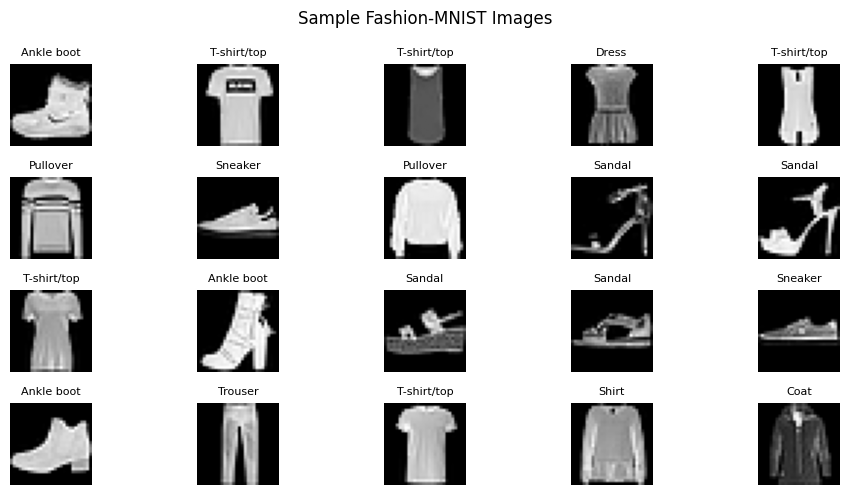

In [ ]:
# Visualize a sample grid of images
plt.figure(figsize=(10, 5))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(CLASS_NAMES[y_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()


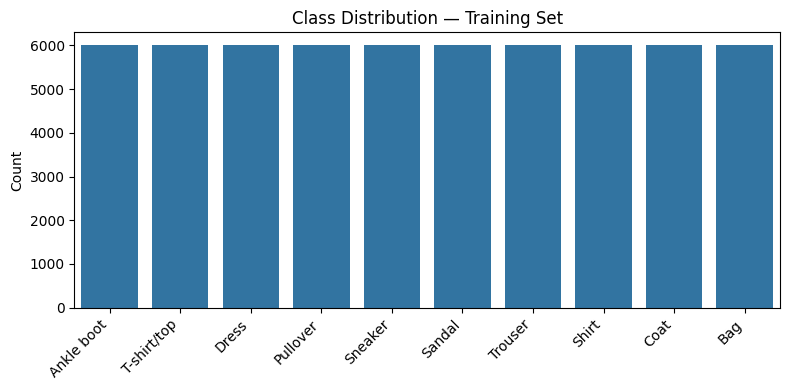

In [ ]:
# Class distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=[CLASS_NAMES[l] for l in y_train])
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution — Training Set")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 3. Preprocessing

In [ ]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to add channel dimension (needed for CNN)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Split a validation set from training data
val_split = 5000
x_val, y_val = x_train[:val_split], y_train[:val_split]
x_train_final, y_train_final = x_train[val_split:], y_train[val_split:]

print("Final train:", x_train_final.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)


Final train: (55000, 28, 28, 1)
Validation: (5000, 28, 28, 1)
Test: (10000, 28, 28, 1)


## 4. Build the CNN Classifier

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. Train the Model (Real-Time Output)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True
)

history = model.fit(
    x_train_final, y_train_final,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1   # <-- real-time per-epoch output in Colab
)


Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.8388 - loss: 0.4609 - val_accuracy: 0.6972 - val_loss: 1.0149
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8942 - loss: 0.2936 - val_accuracy: 0.9028 - val_loss: 0.2610
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9082 - loss: 0.2488 - val_accuracy: 0.8998 - val_loss: 0.2721
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9191 - loss: 0.2199 - val_accuracy: 0.9192 - val_loss: 0.2207
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9282 - loss: 0.1960 - val_accuracy: 0.9072 - val_loss: 0.2618
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9332 - loss: 0.1796 - val_accuracy: 0.9030 - val_loss: 0.2732
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9401 - loss: 0.1599 - val_accuracy: 0.9240 - val_loss: 0.2042
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9457 - loss: 0.1439 - val_accuracy:

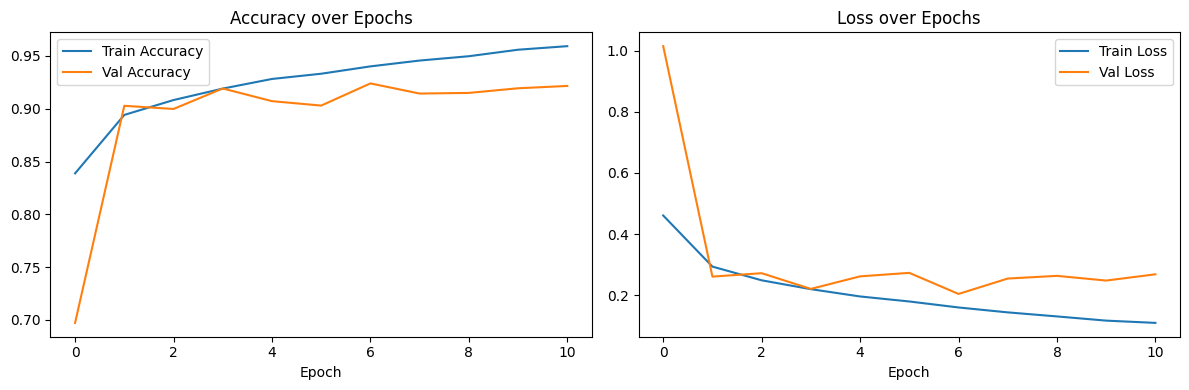

In [ ]:
# Plot training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Accuracy over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Loss over Epochs')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.savefig('accuracy_loss.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Evaluate on Test Set

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 91.83%
Test Loss: 0.2454


In [ ]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

 T-shirt/top       0.86      0.87      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.84      0.92      0.88      1000
       Dress       0.92      0.93      0.92      1000
        Coat       0.86      0.88      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.82      0.69      0.75      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



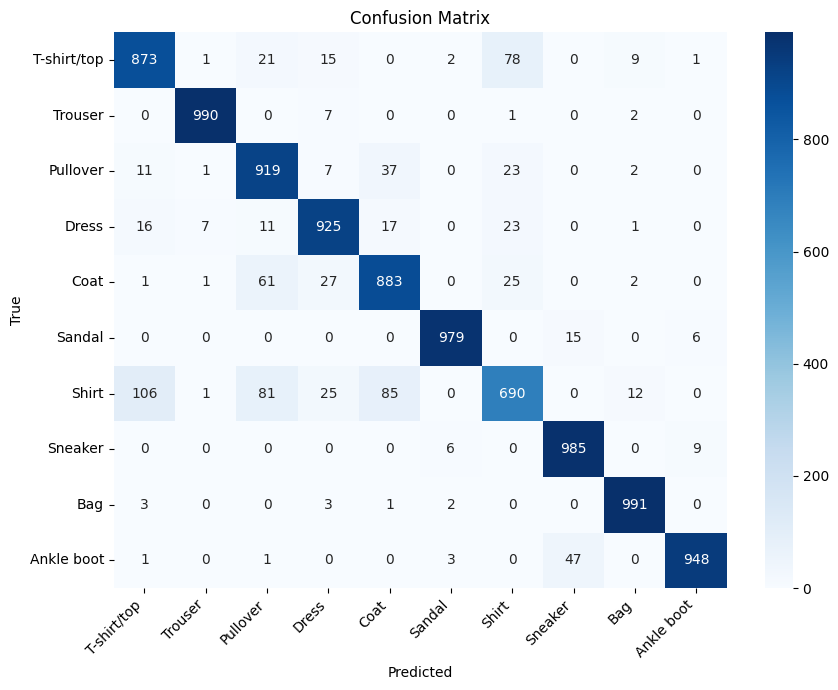

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


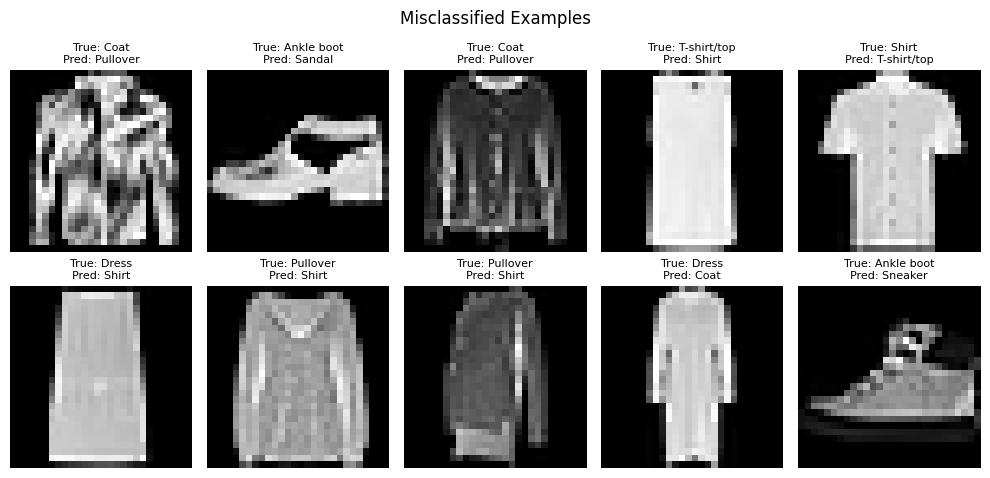

In [ ]:
# Show a few misclassified examples
misclassified = np.where(y_pred != y_test)[0]
plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=8)
    plt.axis('off')
plt.suptitle("Misclassified Examples")
plt.tight_layout()
plt.savefig('misclassified.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# Save the trained classifier
model.save("fashion_cnn_model.keras")
print("Model saved as fashion_cnn_model.keras")


Model saved as fashion_cnn_model.keras


## 7. Visualizing What the CNN Learned

Before moving to the recommendation layer, let's peek inside the CNN itself —
what do the convolutional filters actually respond to? We build a small "activation
model" that outputs the intermediate feature maps for a sample image, then plot them
as heatmaps for each convolutional block.


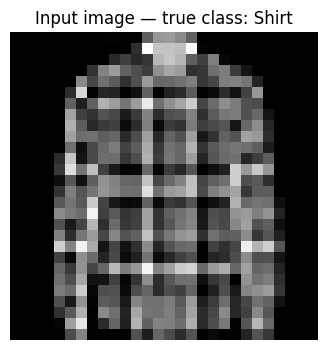

In [ ]:
# Grab the outputs of every Conv2D layer in the model
conv_layers = [layer for layer in model.layers if isinstance(layer, layers.Conv2D)]
activation_model = keras.Model(inputs=model.inputs, outputs=[l.output for l in conv_layers])

# Pick a sample test image to visualize
sample_idx = 7
sample_img = x_test[sample_idx].reshape(1, 28, 28, 1)
sample_label = CLASS_NAMES[y_test[sample_idx]]

activations = activation_model.predict(sample_img, verbose=0)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img.reshape(28, 28), cmap='gray')
plt.title(f"Input image — true class: {sample_label}")
plt.axis('off')
plt.show()


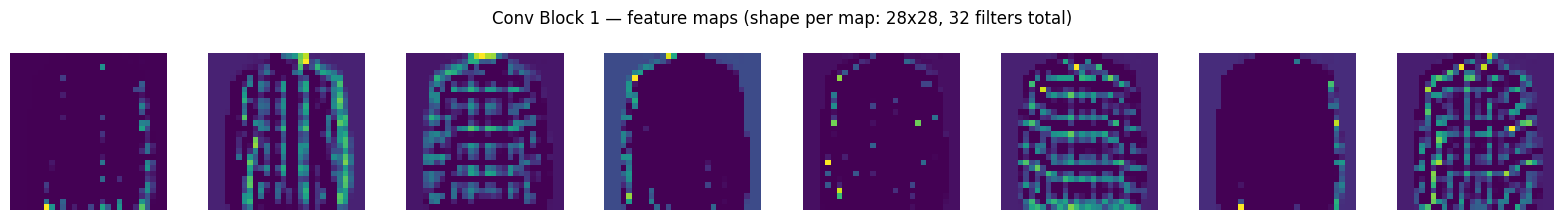

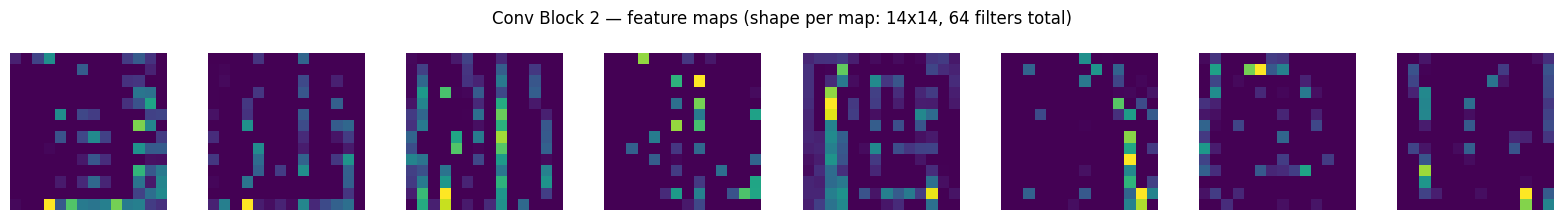

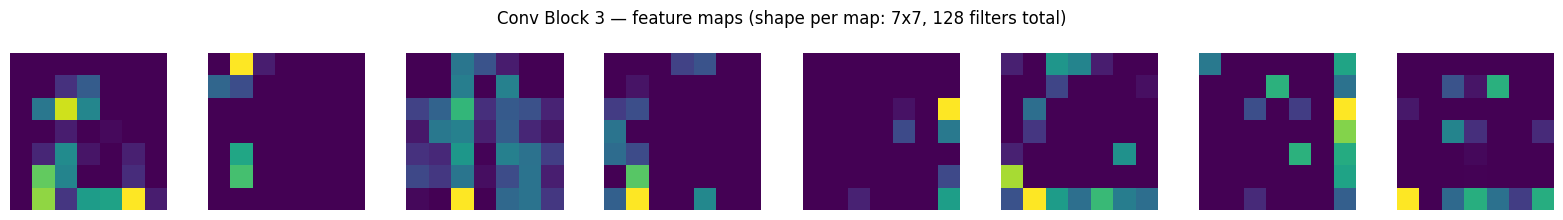

In [ ]:
# Plot a grid of feature maps for each conv block (first 8 filters per block)
for block_idx, act in enumerate(activations):
    n_filters = min(8, act.shape[-1])
    fig, axes = plt.subplots(1, n_filters, figsize=(2 * n_filters, 2.2))
    for i in range(n_filters):
        ax = axes[i] if n_filters > 1 else axes
        ax.imshow(act[0, :, :, i], cmap='viridis')
        ax.axis('off')
    fig.suptitle(f"Conv Block {block_idx + 1} — feature maps "
                 f"(shape per map: {act.shape[1]}x{act.shape[2]}, {act.shape[-1]} filters total)")
    plt.tight_layout()
    plt.savefig('feature_maps.png', bbox_inches='tight', dpi=150)
    plt.show()


**What this shows:** early conv blocks pick up simple patterns like edges and
outlines of the garment, while deeper blocks respond to more abstract, higher-level
shapes as the spatial resolution shrinks. This is good evidence to show in a presentation
that the CNN is learning meaningful structure, not just memorizing pixels.


## 8. LLM-Based Outfit Recommendation

Fashion-MNIST images are grayscale, single-item, and 28x28 — there's no color or style
information for the LLM to see. So the LLM reasons from the **predicted class name**
(and optional user context like occasion/season) rather than the raw pixels.

We use **Flan-T5** (`google/flan-t5-base`) via HuggingFace `transformers` — it's free,
runs locally in Colab (CPU or GPU), and needs no API key, so it stays fully self-contained
and works in real time.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

LLM_MODEL_NAME = "google/flan-t5-large"

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(LLM_MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
llm_model = llm_model.to(device)

CATEGORY_CONTEXT = {
    "T-shirt/top": "a top",
    "Trouser":     "a bottom (trousers)",
    "Pullover":    "a top (pullover sweater)",
    "Dress":       "a dress",
    "Coat":        "an outer layer (coat)",
    "Sandal":      "a pair of sandals (footwear)",
    "Shirt":       "a top (shirt)",
    "Sneaker":     "a pair of sneakers (footwear)",
    "Bag":         "a bag (accessory)",
    "Ankle boot":  "a pair of ankle boots (footwear)",
}

def suggest_outfit(predicted_class, occasion="casual day out", season="any season"):
    item_desc = CATEGORY_CONTEXT.get(predicted_class, predicted_class)

    # Structured, labeled fields make T5 actually condition on occasion/season,
    # instead of burying them inside a long sentence where it tends to ignore them.
    prompt = (
        f"Item owned: {item_desc}\n"
        f"Occasion: {occasion}\n"
        f"Season: {season}\n"
        f"Task: You are a fashion stylist. Recommend a top, bottom, footwear, and one "
        f"accessory to complete an outfit around the item owned, appropriate specifically "
        f"for the occasion and season listed above. Your answer must explicitly mention "
        f"the occasion and season, and the recommendation should change if the occasion or "
        f"season changes. Answer in 2-3 concrete sentences."
    )

    inputs = llm_tokenizer(prompt, return_tensors="pt").to(device)
    output_ids = llm_model.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=4,
        do_sample=True,          # small amount of sampling ON TOP of beams = more variation
        temperature=0.7,
        top_p=0.9,
        no_repeat_ngram_size=3,
        early_stopping=True,
    )
    return llm_tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Quick test — compare these two, they should now differ meaningfully
print(suggest_outfit("Dress", occasion="evening dinner", season="summer"))
print(suggest_outfit("Dress", occasion="office meeting", season="winter"))

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

For evening dinner, wear a dress.
For an office meeting, wear a dress.


## 9. Styled Outfit Card Display

Instead of printing plain text, let's render the classification + LLM suggestion as a
small styled HTML "product card" — much more presentable in a live demo or screen-share
than raw print statements.


In [ ]:
import io
import base64
from IPython.display import HTML, display

def _image_array_to_base64(img_array):
    """Convert a 28x28 numpy array into a base64 PNG string for embedding in HTML."""
    fig, ax = plt.subplots(figsize=(2, 2))
    ax.imshow(img_array.reshape(28, 28), cmap='gray')
    ax.axis('off')
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

def render_outfit_card(img_array, predicted_class, confidence, suggestion, occasion, season):
    img_b64 = _image_array_to_base64(img_array)
    card_html = f"""
    <div style="display:flex; font-family:Arial, sans-serif; max-width:700px;
                border:1px solid #e0d6c8; border-radius:14px; overflow:hidden;
                box-shadow:0 4px 12px rgba(0,0,0,0.08); background:#fffaf3;">
        <img src="data:image/png;base64,{img_b64}"
             style="width:150px; height:150px; object-fit:contain; background:#2b1520; padding:12px;" />
        <div style="padding:16px 20px;">
            <div style="font-size:12px; color:#8a7268; text-transform:uppercase; letter-spacing:1px;">
                Predicted Class
            </div>
            <div style="font-size:22px; font-weight:bold; color:#6d2e46; margin-bottom:6px;">
                {predicted_class} <span style="font-size:13px; color:#a26769; font-weight:normal;">
                ({confidence*100:.1f}% confidence)</span>
            </div>
            <div style="font-size:12px; color:#8a7268; margin-bottom:2px;">
                Occasion: <b>{occasion}</b> &nbsp;|&nbsp; Season: <b>{season}</b>
            </div>
            <div style="margin-top:10px; font-size:14px; color:#3a2530; line-height:1.5;
                        background:#ece2d0; padding:10px 12px; border-radius:8px;">
                {suggestion}
            </div>
        </div>
    </div>
    """
    display(HTML(card_html))


## 10. End-to-End Real-Time Demo

Pick a random test image (or upload your own), classify it with the CNN,
then generate a matching outfit suggestion with the LLM — all in real time,
rendered as a styled card.


In [ ]:
# Safety check: make sure `model` still refers to the CNN classifier (Keras Sequential),
# not to the LLM. If you re-ran cells out of order and this fails, re-run the CNN
# training cell (section 4-5) or reload it with:
#   model = keras.models.load_model("fashion_cnn_model.keras")
assert isinstance(model, keras.Model), (
    "`model` is not the CNN classifier anymore — re-run the training cell or "
    "reload it with keras.models.load_model('fashion_cnn_model.keras')"
)

def classify_image(img_array):
    """img_array: 28x28 grayscale numpy array, values 0-255 or 0-1"""
    img = img_array.astype("float32")
    if img.max() > 1.0:
        img = img / 255.0
    img = img.reshape(1, 28, 28, 1)
    pred = model.predict(img, verbose=0)
    class_idx = np.argmax(pred)
    confidence = float(np.max(pred))
    return CLASS_NAMES[class_idx], confidence

def full_recommendation_pipeline(img_array, occasion="casual day out", season="any season"):
    predicted_class, confidence = classify_image(img_array)
    suggestion = suggest_outfit(predicted_class, occasion, season)
    render_outfit_card(img_array, predicted_class, confidence, suggestion, occasion, season)
    return predicted_class, suggestion



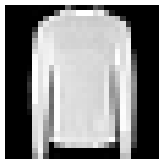

In [ ]:
# Demo on a random test image
random_idx = np.random.randint(0, len(x_test))
_ = full_recommendation_pipeline(x_test[random_idx], occasion="office meeting", season="summer")


In [ ]:
# Optional: upload your own 28x28-ish grayscale clothing image in Colab.
# RUN_UPLOAD_DEMO = False by default so this cell doesn't block "Run all" waiting
# for a file. Set it to True and run this cell again when you want to try your own photo.

RUN_UPLOAD_DEMO = False

if RUN_UPLOAD_DEMO:
    from google.colab import files
    from PIL import Image

    uploaded = files.upload()
    for fname in uploaded.keys():
        img = Image.open(fname).convert('L').resize((28, 28))
        img_array = np.array(img)
        # Fashion-MNIST has white-on-black items (light garment, dark background).
        # If your photo is a normal dark-on-light photo, uncomment the line below —
        # predictions will look wrong/random otherwise.
        # img_array = 255 - img_array
        _ = full_recommendation_pipeline(img_array, occasion="weekend outing", season="monsoon")
else:
    print("Set RUN_UPLOAD_DEMO = True above and re-run this cell to test your own image.")


Set RUN_UPLOAD_DEMO = True above and re-run this cell to test your own image.


## 11. Interactive Gradio Demo

Let's wrap the full pipeline in a simple web UI using Gradio — upload an image, pick an
occasion and season, and get the predicted class + styled outfit suggestion back as a
live app instead of running cells manually. This is the most presentation-friendly way
to demo the project live.


In [ ]:
!pip install -q gradio


In [ ]:
import gradio as gr
from PIL import Image as PILImage

OCCASIONS = ["casual day out", "office meeting", "evening dinner", "weekend outing", "festive occasion"]
SEASONS = ["any season", "summer", "winter", "monsoon"]

def gradio_predict(input_image, occasion, season):
    if input_image is None:
        return "<p style='color:#8a7268;'>Please upload a clothing image to get a recommendation.</p>"

    img = PILImage.fromarray(input_image).convert('L').resize((28, 28))
    img_array = np.array(img)

    predicted_class, confidence = classify_image(img_array)
    suggestion = suggest_outfit(predicted_class, occasion, season)

    # Reuse the same base64-image helper from the styled outfit card section
    img_b64 = _image_array_to_base64(img_array)
    return f"""
    <div style="display:flex; font-family:Arial, sans-serif; max-width:700px;
                border:1px solid #e0d6c8; border-radius:14px; overflow:hidden;
                box-shadow:0 4px 12px rgba(0,0,0,0.08); background:#fffaf3;">
        <img src="data:image/png;base64,{img_b64}"
             style="width:150px; height:150px; object-fit:contain; background:#2b1520; padding:12px;" />
        <div style="padding:16px 20px;">
            <div style="font-size:12px; color:#8a7268; text-transform:uppercase; letter-spacing:1px;">
                Predicted Class
            </div>
            <div style="font-size:22px; font-weight:bold; color:#6d2e46; margin-bottom:6px;">
                {predicted_class} <span style="font-size:13px; color:#a26769; font-weight:normal;">
                ({confidence*100:.1f}% confidence)</span>
            </div>
            <div style="font-size:12px; color:#8a7268; margin-bottom:2px;">
                Occasion: <b>{occasion}</b> &nbsp;|&nbsp; Season: <b>{season}</b>
            </div>
            <div style="margin-top:10px; font-size:14px; color:#3a2530; line-height:1.5;
                        background:#ece2d0; padding:10px 12px; border-radius:8px;">
                {suggestion}
            </div>
        </div>
    </div>
    """

demo_ui = gr.Interface(
    fn=gradio_predict,
    inputs=[
        gr.Image(type="numpy", label="Upload a clothing image"),
        gr.Dropdown(OCCASIONS, value="casual day out", label="Occasion"),
        gr.Dropdown(SEASONS, value="any season", label="Season"),
    ],
    outputs=gr.HTML(label="Recommendation"),
    title="👗 Fashion Recommendation System",
    description="Upload a clothing item — a CNN classifies it, then an LLM suggests a matching outfit.",
)

# share=True gives you a public link you can demo from any device during your presentation
demo_ui.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f66225d10a0e3b67b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Conclusion & Future Work

**Summary:**
- Trained a CNN on Fashion-MNIST achieving strong test accuracy on 10 clothing categories
- Visualized the CNN's internal feature maps to confirm it learns meaningful structure
- Built an LLM-based recommendation layer (Flan-T5) that turns a predicted class into a
  natural-language, context-aware outfit suggestion
- Rendered results as styled outfit cards and wrapped the whole pipeline in a live Gradio app
- Combined everything into a single real-time pipeline: image → classification → styled recommendation

**Limitations:**
- Fashion-MNIST is grayscale and single-item, so the LLM never sees color/pattern/fit —
  it only reasons from the class label and user-given context (occasion/season)
- Flan-T5-base is a small model; outfit suggestions are plausible but generic compared to
  a larger LLM or one fine-tuned on fashion-specific data

**Future Work:**
- Swap in a color/full-outfit dataset (e.g., DeepFashion) for richer visual grounding
- Fine-tune the LLM on fashion-specific outfit-pairing data
- Add a retrieval step: recommend actual matching items from a small product catalog
  instead of only generating free-text suggestions
- Deploy as a simple web app (Streamlit/Gradio) for interactive use
